# Learning Hugging Face Text Classification Tutorial

* Resource notebook: https://www.learnhuggingface.com/notebooks/hugging_face_text_classification_tutorial

Note : GPU is needed in Google Colab


### 1. Import necessary libraries


In [3]:
# Install dependancies (this is mostly for Google Colab )

try :
  import datasets,evaluate,accelerate
  import gradio as gr
except ModuleNotFoundError:
  !pip install -U datasets evaluate accelerate gradio
  import datasets,evaluate,accelerate
  import gradio as gr

import random
import numpy as np
import pandas as pd
import torch
import transformers

print(f"Using transformers version{transformers.__version__}")
print(f"Using torch version{torch.__version__}")
print(f"Using datasets version{datasets.__version__}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.7/354.7 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.9/183.9 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## 2. Getting a dataset

Building food not food text classification model : need food not food text dataset



In [4]:
from datasets import load_dataset

dataset = load_dataset("mrdbourke/learn_hf_food_not_food_image_captions")
dataset

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/1.32k [00:00<?, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/11.9k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/250 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 250
    })
})

In [ ]:
# What features are there?
dataset.column_names

{'train': ['text', 'label']}

In [ ]:
# Access the training split
dataset["train"][10]

{'text': 'Set of golf clubs stored in a bag', 'label': 'not_food'}

In [ ]:
### Inspect random samples

random_indeces = random.sample(range(len(dataset["train"])),5)
random_indeces

random_samples = dataset["train"][random_indeces]
print(f"[INFO] Random samples from dataset:\n)")
for text,label in zip(random_samples["text"],random_samples["label"]):
  print(f"Text : {text} | Label : {label}")

[INFO] Random samples from dataset:
)
Text : Wooden hanger holding clothes on a rack | Label : not_food
Text : Luxurious coconut shrimp curry on a generous plate, featuring succulent shrimp in a rich coconut milk sauce, served with jasmine rice. | Label : food
Text : A bowl of sliced tomatoes with a sprinkle of basil and a side of mozzarella cheese | Label : food
Text : Set of plates stacked in a cupboard | Label : not_food
Text : Set of candles arranged on a mantel | Label : not_food


In [ ]:
# Get unique label values
dataset["train"].unique("label")

['food', 'not_food']

In [3]:
# Check the count of each label
from collections import Counter

Counter(dataset["train"]["label"])

Counter({'food': 125, 'not_food': 125})

In [ ]:
# Turn our dataset into a DataFrame and get a random sample

food_not_food_df = pd.DataFrame(dataset["train"])
food_not_food_df.head(7)

,text,label
0,"Creamy cauliflower curry with garlic naan, fea...",food
1,Set of books stacked on a desk,not_food
2,"Watching TV together, a family has their dog s...",not_food
3,Wooden dresser with a mirror reflecting the room,not_food
4,Lawn mower stored in a shed,not_food
5,Coffee table cluttered with magazines,not_food
6,Pair of reading glasses left open on a book,not_food


In [ ]:
food_not_food_df["label"].value_counts()

,count
label,
food,125
not_food,125


## 3. Preparing data for text classification

We want to :
1. Tokenize our text - turn our text into numbers
2. Create a train/test split - want to train our model on the training set and evaluate on the test set


In [ ]:
# Create a mapping for labels to numeric values
id2label = {0 : "not_food", 1:"food"}
label2id = {"not_food":0,"food":1}
print(id2label)
print(label2id)

{0: 'not_food', 1: 'food'}
{'not_food': 0, 'food': 1}


In [5]:
# Create mapping programmatically
id2label = {idx : label for idx,label in enumerate(dataset["train"].unique("label")[::-1]) }
label2id = {label : idx for idx,label in id2label.items()}
print(id2label )
print(label2id)

{0: 'not_food', 1: 'food'}
{'not_food': 0, 'food': 1}


In [ ]:
id2label = {}
for idx, label in enumerate(dataset["train"].unique("label")[::-1]):
  print(idx,label)
  id2label[idx] = label

0 not_food
1 food


In [6]:
# Turn labels into 0 or 1
def map_labels_to_number(example):
  example["label"] = label2id[example["label"]]
  return example

example_sample = {"text": "This is a sentence about my favourite food:honey","label":"food"}

# Test our function
map_labels_to_number(example_sample)

{'text': 'This is a sentence about my favourite food:honey', 'label': 1}

In [7]:
# Map our dataset labels to numbers (the whole thing)
# We can do this with dataset.map()
dataset = dataset["train"].map(map_labels_to_number)
dataset[:5]

Map:   0%|          | 0/250 [00:00<?, ? examples/s]

{'text': ['Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
  'Set of books stacked on a desk',
  'Watching TV together, a family has their dog stretched out on the floor',
  'Wooden dresser with a mirror reflecting the room',
  'Lawn mower stored in a shed'],
 'label': [1, 0, 0, 0, 0]}

In [ ]:
# Shuffle data and look at 5 more random samples
dataset.shuffle()[:5]

{'text': ['Crunchy sushi roll with a creamy filling, featuring shrimp tempura and avocado.',
  'A slice of pizza with a pesto base, topped with grilled vegetables and a balsamic glaze',
  'Set of plates stacked in a cupboard',
  'Celery in a bowl, served with a side of peanut butter and a sprinkle of raisins for a classic, tasty snack.',
  'A square slice of Sicilian-style pizza with a thick and fluffy crust'],
 'label': [1, 1, 0, 1, 1]}

### 4. Splitting data into training and test sets

* Train set = model will learn patterns on this dataset
* Test set = model will evaluate patterns on this dataset

We can split our dataset using `datasets.Dataset.train_test_split´


In [8]:
# Split our dataset into train/test split
dataset = dataset.train_test_split(test_size=0.2,seed=42)
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 50
    })
})

In [ ]:
random_idx_train = random.randint(0,len(dataset["train"]))
random_sample_train = dataset["train"][random_idx_train]
random_sample_train



{'text': 'Creamy cauliflower curry with garlic naan, featuring tender cauliflower in a rich sauce with cream and spices, served with garlic naan bread.',
 'label': 1}

In [ ]:
random_idx_test = random.randint(0,len(dataset["test"]))
random_sample_test = dataset["test"][random_idx_test]
random_sample_test

{'text': 'Green beans in a bowl, sprinkled with almonds and served with a side of lemon vinaigrette for a healthy, tasty dish.',
 'label': 1}

### Tokenizing our text data(turning text into numbers)
The premise of tokenization is to turn words into numbers

___

The `transformers` library has in-built support for the HuggingFace tokenizers

And the class `transformers.AutoTokenizer` helps pair a model to a tokenizer

* Model/tokenizer we're going to use : distilbert/distilbert-base-uncased

* All models :https://huggingface.co/models?sort=trending

* Models are often paired with tokenizers
* Tokenizer = turn text into numbers
* Model = find patterns in those numbers


In [9]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path="distilbert/distilbert-base-uncased",
                                          use_fast=True)#use the fast implementation (on by default , this requires Rust installed)

tokenizer

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

DistilBertTokenizerFast(name_or_path='distilbert/distilbert-base-uncased', vocab_size=30522, model_max_length=512, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'unk_token': '[UNK]', 'sep_token': '[SEP]', 'pad_token': '[PAD]', 'cls_token': '[CLS]', 'mask_token': '[MASK]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	0: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	100: AddedToken("[UNK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	101: AddedToken("[CLS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	102: AddedToken("[SEP]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	103: AddedToken("[MASK]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [ ]:
# Test out the to")kenizer
tokenizer("I love pizza")

{'input_ids': [101, 1045, 2293, 10733, 102], 'attention_mask': [1, 1, 1, 1, 1]}

* input_ids = our text turned into numbers
* attention_mask = whether or not to pay attention to certain tokens

In [ ]:
tokenizer("I love pizza!")

{'input_ids': [101, 1045, 2293, 10733, 999, 102], 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [ ]:
# Get the length of our tokenizer vocab
length_of_tokenizer_vocab = len(tokenizer.vocab)
print(f"[Info] Number of items in our tokenizer vocabulary: {length_of_tokenizer_vocab}")

# Get the maximum sequence length the tokenizer can handle
max_tokenizer_input_sequence_length = tokenizer.model_max_length
print(f"[Info] Max tokenizer input sequence length:{max_tokenizer_input_sequence_length}")


[Info] Number of items in our tokenizer vocabulary: 30522
[Info] Max tokenizer input sequence length:512


In [ ]:
tokenizer("akash")

{'input_ids': [101, 9875, 4095, 102], 'attention_mask': [1, 1, 1, 1]}

In [ ]:
tokenizer.convert_ids_to_tokens(tokenizer("akash").input_ids)

['[CLS]', 'aka', '##sh', '[SEP]']

In [ ]:
tokenizer.convert_ids_to_tokens(tokenizer("🍔").input_ids)


['[CLS]', '[UNK]', '[SEP]']

In [ ]:
# Get the first 5 items in the tokenizer vocab
sorted(tokenizer.vocab.items())[:5]

[('!', 999), ('"', 1000), ('#', 1001), ('##!', 29612), ('##"', 29613)]

In [ ]:
import random
random.sample(sorted(tokenizer.vocab.items()),5)

[('cut', 3013),
 ('suez', 21974),
 ('resources', 4219),
 ('additive', 29167),
 ('popularly', 16071)]

### Making a preprocessing function to tokenize text

Want to make it easy to go from sample to tokenized sample


In [10]:
def tokenize_text(examples):
  """
  Tokenize given example text and return the
  tokenized text
  """

  return tokenizer(examples["text"],
                   padding=True,#pad short sequences to the longest sequence length in batch
                   truncation=True)#truncate long sequences to the maximum length the model can handle




In [ ]:
example_sample_2 = {"text":"I love pizza","label":1}

# Test the function
tokenize_text(example_sample_2)

{'input_ids': [101, 1045, 2293, 10733, 102], 'attention_mask': [1, 1, 1, 1, 1]}

In [ ]:
long_text = "I love pizza " * 1000
len(long_text)

13000

In [ ]:
tokenized_long_text = tokenize_text({"text": long_text,label : 1})
len(tokenized_long_text["input_ids"])

512

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 50
    })
})

In [11]:
# Map our tokenite-text function to the dataset
tokenized_dataset = dataset.map(function=tokenize_text,
                               batched = True , # set batched=True to tokenize across batches of samples at a time rather than one at a time
                                batch_size=1000)
tokenized_dataset


Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 200
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'attention_mask'],
        num_rows: 50
    })
})

**Note:** In ML it is often faster to do things in batches rather than one at a time due to leveraging computer hardware parallelization

In [ ]:
tokenizer.all_special_tokens

['[UNK]', '[SEP]', '[PAD]', '[CLS]', '[MASK]']

In [ ]:
tokenizer.all_special_ids

[100, 102, 0, 101, 103]

In [ ]:
# Get 2 samples from the tokenized datasets
train_tokenized_sample = tokenized_dataset["train"][0]
test_tokenized_sample = tokenized_dataset["test"][0]

for key in train_tokenized_sample.keys():
  print(f"[Info] Key :{key}")
  print(f"Train sample: {train_tokenized_sample[key]}")
  print(f"Test sample: {test_tokenized_sample[key]}")

[Info] Key :text
Train sample: Set of headphones placed on a desk
Test sample: A slice of pepperoni pizza with a layer of melted cheese
[Info] Key :label
Train sample: 0
Test sample: 1
[Info] Key :input_ids
Train sample: [101, 2275, 1997, 2132, 19093, 2872, 2006, 1037, 4624, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test sample: [101, 1037, 14704, 1997, 11565, 10698, 10733, 2007, 1037, 6741, 1997, 12501, 8808, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
[Info] Key :attention_mask
Train sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
Test sample: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


### Tokenization takeaways

1. Tokenization = turn data into numbers (e.g. text -> map to number)
2. Many models are out there and have different tokenizers, Hugging Face's `Auto` (e.g. `AutoTokenizer`,`AutoProcessor`,`AutoModel`...) help to match tokenizers to models
3. Tokenization can happen in parallel using `map` and batched functions


## Setting up an evaluation metric

What we want to do is : use the evaluation metric to get a numerical idea of how our model is performing

Some common evaluation metrics for classifiction :

-Accuracy(how many examples out of 100 did you get correct?)
-Precision
-Recall
-F1 score

Evaluation metric is important because some projects may have an evaluation threshold you need to fulfill

Some places for evaluation metrics:


- Scikit-learn documentation : https://scikit-learn.org/stable/modules/model_evaluation.html

- Hugging Face evaluate : https://huggingface.co/docs/evaluate/index


In [12]:
import evaluate
import numpy as np
from typing import Tuple

accuracy_metric = evaluate.load("accuracy")

def compute_accuracy(predictions_and_labels: Tuple[np.array,np.array]):
  """
  Computes the accuracy of a model by comparing the
  predictions and labels
  """
  predictions,labels = predictions_and_labels

  if len(predictions.shape) >= 2 :
    predictions = np.argmax(predictions,axis=1)

  return accuracy_metric.compute(predictions=predictions,references=labels)


In [ ]:
# Example predictions and accuracy score
example_preds_all_correct = np.array([0,0,0,0,0,0,0,0,0,0])
example_preds_one_incorrect = np.array([0,0,0,0,1,0,0,0,0,0])
example_labels = np.array([0,0,0,0,0,0,0,0,0,0])

# test the function
print(f"Accuracy when all predictions are correct: {compute_accuracy((example_preds_all_correct,example_labels))} ")
print(f"Accuracy when one prediction is incorrect: {compute_accuracy((example_preds_one_incorrect,example_labels))} ")

Accuracy when all predictions are correct: {'accuracy': 1.0} 
Accuracy when one prediction is incorrect: {'accuracy': 0.9} 


## Setting up a model for training

* We're going to be using transfer learning.
* Transfer learning is a powerful technique,unique to deep learning models that enables us to use the  patterns one model has learned on another problem for our own problem

Workflow for training:
1. Create and preprocess data(we've actually done that already)
2. Define the model we'd like to use for our problem
3. Define training arguments for training our model `transformers.TrainingArguments`
* These are also known as "hyperparameters"=settings on your model that you can adjust
* Parameters=weights/patterns in the model,that get updated automatically
4. Pass `TrainingArguments` to an instance of `transformers.Trainer`
5. Train the model by calling `Trainer.train()`
6. Save the model to our local machine or to the Hugging Face Hub
7. Evaluate the trained model by making and inspecting predictions on the test data (and our own custom data)
8. Turn the model into a sharable demo

In [ ]:
id2label

{0: 'not_food', 1: 'food'}

In [ ]:
label2id

{'not_food': 0, 'food': 1}

In [13]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    pretrained_model_name_or_path="distilbert/distilbert-base-uncased",
    num_labels=2, # classify into food/not_food
    id2label=id2label,
    label2id=label2id)


Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert/distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


Our model is comprised of the following parts :
1. `embeddings` - embeddings are a form of learned representation of tokens. So if tokens are a direct mapping from token to number,embeddings are a learned vector representation
2. `transformer` - our model architecture backbone,this has discovered patterns/relationships in the embeddings
3. `classifier` - we need to customize this layer to suit our problem

**Note:** If you get input errors from passing a sample to a model,make sure the sample you pass to the model is formatting in the same way the model was trained on.for example if your model uses a specific tokenizer,make sure to tokenize your text before passing it to the model

In [ ]:
model(**tokenized_dataset["train"][0])

{'text': 'Set of headphones placed on a desk',
 'label': 0,
 'input_ids': [101,
  2275,
  1997,
  2132,
  19093,
  2872,
  2006,
  1037,
  4624,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0]}

### Count the parameters in our model

Weights/parameters = small numeric opportunities for a model to learn patterns in data

In [14]:
def count_params(model):
  """
  Count the parameters of a PyTorch model
  """
  trainable_parameters = sum(param.numel() for param in model.parameters() if param.requires_grad)
  total_parameters = sum(param.numel() for param in model.parameters())

  return {"trainable_parameters" : trainable_parameters,"total_parameters": total_parameters}

count_params(model)


{'trainable_parameters': 66955010, 'total_parameters': 66955010}

Looks like our model has around 67M parameters and all of them are trainable.

**Note:**
* Generally,the more parameters-the more capacity it has to learn
* If you want the best possible performance - generally more parameters is better
  * However more params require more compute time


### Create a folder/directory for saving models


In [15]:
# Create model output directory

from pathlib import Path

# Create models directory
models_dir = Path("models")
models_dir.mkdir(parents=True,exist_ok=True)

#  Create model save name
model_save_name = "learn-hf-food-not_food-text-classification-model-distilbert-base-uncased"

# Create model save path
model_save_dir = Path(models_dir,model_save_name)

model_save_dir

PosixPath('models/learn-hf-food-not_food-text-classification-model-distilbert-base-uncased')

### Setting up hyperparameters with TrainingArguments

In [16]:
from transformers import TrainingArguments

print(f"[Info] Saving model checkpoints: {model_save_dir} ")

#Create training arguments
training_args = TrainingArguments(
    output_dir=model_save_dir,
    learning_rate=0.0001,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=3,
    use_cpu=False,
    seed=42,
    load_best_model_at_end=True,
    logging_strategy="epoch",
    report_to="none",
    hub_private_repo=False
)

[Info] Saving model checkpoints: models/learn-hf-food-not_food-text-classification-model-distilbert-base-uncased 


### Setting up an instance of Trainer

In [17]:
from transformers import Trainer

# Setup Trainer
trainer= Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_accuracy
)

trainer

<ipython-input-17-5e290670fca6>:4: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer= Trainer(


### Train the model by calling trainer.train()

In [18]:
results = trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.427100,0.074981,1.000000
2,0.034200,0.007267,1.000000
3,0.005000,0.002271,1.000000
4,0.002000,0.001209,1.000000
5,0.001300,0.000835,1.000000
6,0.000900,0.000676,1.000000
7,0.000800,0.000594,1.000000
8,0.000700,0.000551,1.000000
9,0.000600,0.000529,1.000000
10,0.000600,0.000521,1.000000


In [19]:
# Inspect training metrics
for key,value in results.metrics.items():
  print(f"{key} : {value}")

train_runtime : 428.8163
train_samples_per_second : 4.664
train_steps_per_second : 0.163
total_flos : 18110777160000.0
train_loss : 0.047307225702596566
epoch : 10.0


### Save the model for later use

**Note:** If you are saving a model to Google Colab, it will disappear from your Colab instance when it disconnects

In [20]:
# Save the model
print(f"[Info] Saving model to {model_save_dir}")
trainer.save_model(output_dir=model_save_dir)

[Info] Saving model to models/learn-hf-food-not_food-text-classification-model-distilbert-base-uncased


### Inspect the model training metrics

In [21]:
# Get training history
trainer_history_all = trainer.state.log_history
trainer_history_metrics = trainer_history_all[:-1]
trainer_history_training_time=trainer_history_all[-1]

trainer_history_metrics[:3]

[{'loss': 0.4271,
  'grad_norm': 1.5387630462646484,
  'learning_rate': 9.142857142857143e-05,
  'epoch': 1.0,
  'step': 7},
 {'eval_loss': 0.07498051971197128,
  'eval_accuracy': 1.0,
  'eval_runtime': 2.2676,
  'eval_samples_per_second': 22.05,
  'eval_steps_per_second': 0.882,
  'epoch': 1.0,
  'step': 7},
 {'loss': 0.0342,
  'grad_norm': 0.1493549942970276,
  'learning_rate': 8.142857142857143e-05,
  'epoch': 2.0,
  'step': 14}]

In [28]:
import pprint

# Extract eval and training metrics
trainer_history_training_set = []
trainer_history_eval_set = []

# Loop through our metrics
for item in trainer_history_metrics:
  item_keys = list(item.keys())
  if any("eval" in item for item in item_keys):
    trainer_history_eval_set.append(item)
  else:
    trainer_history_training_set.append(item)

  # Show the first from each
  print(f"First item in training set:")
  pprint.pprint(trainer_history_training_set[:2])
  print(f"First item in eval set:")
  pprint.pprint(trainer_history_eval_set[:2])

First item in training set:
[{'epoch': 1.0,
  'grad_norm': 1.5387630462646484,
  'learning_rate': 9.142857142857143e-05,
  'loss': 0.4271,
  'step': 7}]
First item in eval set:
[]
First item in training set:
[{'epoch': 1.0,
  'grad_norm': 1.5387630462646484,
  'learning_rate': 9.142857142857143e-05,
  'loss': 0.4271,
  'step': 7}]
First item in eval set:
[{'epoch': 1.0,
  'eval_accuracy': 1.0,
  'eval_loss': 0.07498051971197128,
  'eval_runtime': 2.2676,
  'eval_samples_per_second': 22.05,
  'eval_steps_per_second': 0.882,
  'step': 7}]
First item in training set:
[{'epoch': 1.0,
  'grad_norm': 1.5387630462646484,
  'learning_rate': 9.142857142857143e-05,
  'loss': 0.4271,
  'step': 7},
 {'epoch': 2.0,
  'grad_norm': 0.1493549942970276,
  'learning_rate': 8.142857142857143e-05,
  'loss': 0.0342,
  'step': 14}]
First item in eval set:
[{'epoch': 1.0,
  'eval_accuracy': 1.0,
  'eval_loss': 0.07498051971197128,
  'eval_runtime': 2.2676,
  'eval_samples_per_second': 22.05,
  'eval_steps_pe

### Taking a look at the loss curves

Loss curves = a good visualization of your model's performance over time

Ideally,loss curves will trend downwards


In [29]:
# Create a pandas DataFrame for t6he training and evaluation metrics

trainer_history_train_df = pd.DataFrame(trainer_history_training_set)
trainer_history_eval_df = pd.DataFrame(trainer_history_eval_set)

trainer_history_train_df.head()

,loss,grad_norm,learning_rate,epoch,step
0,0.4271,1.538763,0.000091,1.0,7
1,0.0342,0.149355,0.000081,2.0,14
2,0.0050,0.048294,0.000071,3.0,21
3,0.0020,0.024310,0.000061,4.0,28
4,0.0013,0.020529,0.000051,5.0,35


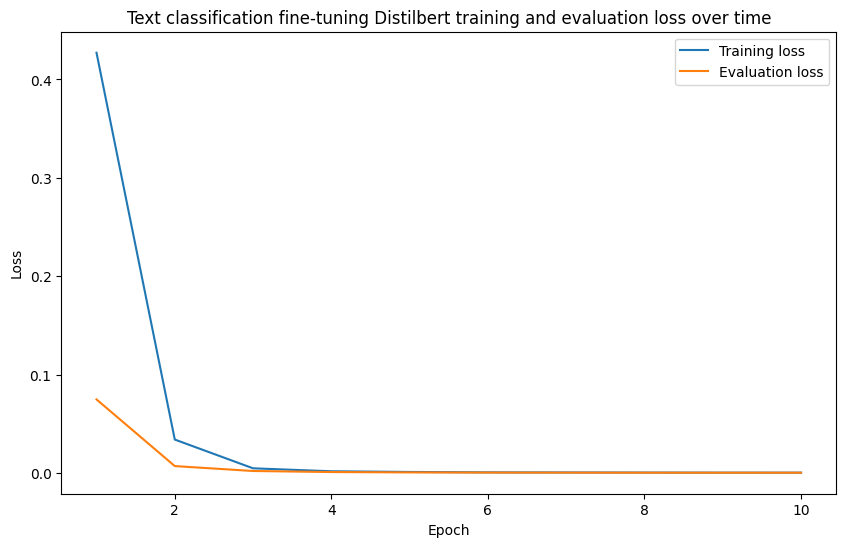

In [31]:
# Plot the loss curves
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(trainer_history_train_df["epoch"],trainer_history_train_df["loss"],label="Training loss")
plt.plot(trainer_history_eval_df["epoch"],trainer_history_eval_df["eval_loss"],label="Evaluation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Text classification fine-tuning Distilbert training and evaluation loss over time")
plt.legend()
plt.show()

### Pushing our model to the HF hub


In [35]:
# Save our model to the HuggingFace hub



model_upload_url = trainer.push_to_hub(
    commit_message="Uploading food not food text classifier model"

)
print(f"Model successfully uploaded to the HuggingFace hub with URL:{model_upload_url}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

training_args.bin:   0%|          | 0.00/5.37k [00:00<?, ?B/s]

Model successfully uploaded to the HuggingFace hub with URL:https://huggingface.co/yjenny2512/learn-hf-food-not_food-text-classification-model-distilbert-base-uncased/tree/main/


### Making and evaluating predictions on  the test data
**Note:** Evaluating a model is just as important as training a model

In [36]:
# Perform predictions on the test data
predictions_all = trainer.predict(tokenized_dataset["test"])
prediction_values = predictions_all.predictions
prediction_metrics = predictions_all.metrics

print(f"Prediction metrics on the test data:")
prediction_metrics

Prediction metrics on the test data:


{'test_loss': 0.0005214678822085261,
 'test_accuracy': 1.0,
 'test_runtime': 6.8034,
 'test_samples_per_second': 7.349,
 'test_steps_per_second': 0.294}

In [37]:
predictions_all

PredictionOutput(predictions=array([[-3.8171146,  3.700601 ],
       [ 3.777048 , -3.8828773],
       [-3.8128967,  3.7105029],
       [ 3.8082423, -3.9071634],
       [ 3.798383 , -3.902357 ],
       [-3.8154006,  3.7094085],
       [ 3.7955883, -3.8931851],
       [ 3.7887864, -3.9103866],
       [-3.800464 ,  3.7096374],
       [-3.7880762,  3.7095737],
       [-3.7919612,  3.7102237],
       [-3.805064 ,  3.6817458],
       [ 3.7918553, -3.9061053],
       [-3.7953172,  3.7123623],
       [-3.8101146,  3.6911073],
       [ 3.794138 , -3.9116926],
       [-3.789831 ,  3.7099328],
       [ 3.773209 , -3.870914 ],
       [-3.794895 ,  3.7129064],
       [-3.795652 ,  3.7107086],
       [-3.8024163,  3.701305 ],
       [-3.7863636,  3.713398 ],
       [ 3.7976153, -3.903819 ],
       [ 3.7903626, -3.9008796],
       [-3.797144 ,  3.7095494],
       [-3.8198445,  3.7024345],
       [-3.7897232,  3.7068624],
       [ 3.7924256, -3.8818595],
       [-3.8248684,  3.7050269],
       [ 3.793

### Predicted logits -> predictions probabilities with torch.softmax -> predicted labels

In [41]:
import torch
from sklearn.metrics import accuracy_score

# softmax gets all values to be between 0 & 1 and all the values sum to 1
# this is known as "prediction probability",as in the model is assigning this value to how "likely" the prediction is given the sample


pred_probs = torch.softmax(torch.tensor(prediction_values),dim=0)

pred_labels = torch.argmax(pred_probs,dim=1)

true_lables = tokenized_dataset["test"]["label"]

test_accuracy = accuracy_score(true_lables,pred_labels)

print(f"Test accuracy: {test_accuracy}")


Test accuracy: 1.0


## Making and inspecting predictions on custom text data

In [44]:
local_model_path = "models/learn-hf-food-not_food-text-classification-model-distilbert-base-uncased"

huggingface_model_path = "yjenny2512/learn-hf-food-not_food-text-classification-model-distilbert-base-uncased"



### Discussing ways to make predictions(inference)

* Note : Whenever you hear the word "inference" it means to use a model to make predictions on data

Two main ways to perform inference:

1. **Pipeline** mode - using `transformers.pipeline` to load our model and perform text classifications

2. **PyTorch** mode - using a combination of `transformers.AutoTokenizer` and `transformers.AutoModelForSequenceClassification` and passing each our target model name

Each mode supports:
1. Predictions one at a time(fast but can be slower with many samples)
2. Batches of predictions at a time(faster but up to a point)

In [42]:
# Setup our device for making predictions

def set_device():
  if torch.cuda.is_available():
    device = torch.device("cuda")
  elif torch.backends.mps.is_available():
    device = torch.device("mps")
  else:
    device = torch.device("cpu")
  return device

device = set_device()
print(f"using device:{device}")
device

using device:cpu


device(type='cpu')

### Making predictions with pipeline mode

In [45]:
import torch
from transformers import pipeline

#Set the batch size
BATCH_SIZE = 32

# Create an instance of transformers.pipeline
food_not_food_classifier = pipeline(task="text-classification",
                                    model=local_model_path,
                                    device=device,
                                    top_k=1,batch_size=BATCH_SIZE
                                    )
food_not_food_classifier

Device set to use cpu


In [53]:
test_custom_sentence = "The Gate by Pete2453"
food_not_food_classifier(test_custom_sentence)

[[{'label': 'not_food', 'score': 0.999352753162384}]]

# Use pipeline with a model from Huggingface


In [ ]:
del pipeline

In [52]:
from transformers import pipeline
food_not_food_classifier = pipeline(task="text-classification",
                                    model=huggingface_model_path,
                                    device=device,
                                    top_k=1,
                                    batch_size=BATCH_SIZE)
food_not_food_classifier(test_custom_sentence
                         )

config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.23k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Device set to use cpu


[[{'label': 'not_food', 'score': 0.9912960529327393}]]

### Making multiple predictions at the same time with batch prediction


In [54]:
# Create a list of sentences to make predictions on
sentences = [
    "I whipped up a fresh batch of code, but it seems to have a syntax error.",
    "We need to marinate these ideas overnight before presenting them to the client.",
    "The new software is definitely a spicy upgrade, taking some time to get used to.",
    "Her social media post was the perfect recipe for a viral sensation.",
    "He served up a rebuttal full of facts, leaving his opponent speechless.",
    "The team needs to simmer down a bit before tackling the next challenge.",
    "The presentation was a delicious blend of humor and information, keeping the audience engaged.",
    "A beautiful array of fake wax foods (shokuhin sampuru) in the front of a Japanese restaurant.",
    "Daniel Bourke is really cool :D",
    "My favoruite food is biltong!"
]

food_not_food_classifier(sentences)

[[{'label': 'not_food', 'score': 0.974435031414032}],
 [{'label': 'not_food', 'score': 0.9985376596450806}],
 [{'label': 'food', 'score': 0.7038679122924805}],
 [{'label': 'not_food', 'score': 0.9964267611503601}],
 [{'label': 'not_food', 'score': 0.9985009431838989}],
 [{'label': 'not_food', 'score': 0.9976248145103455}],
 [{'label': 'not_food', 'score': 0.5701048374176025}],
 [{'label': 'food', 'score': 0.9993960857391357}],
 [{'label': 'not_food', 'score': 0.9984793066978455}],
 [{'label': 'food', 'score': 0.9970322847366333}]]

### Time our model across larger sample sizes


In [59]:
import time

# Create 1000 sentences

sentences_1000 = sentences * 100

len(sentences_1000)

# Time how long it takes to make predictions on all sentences (one at a time)
print(f"Number of sentences: {len(sentences_1000)}")
start_time_one_at_a_time = time.time()
for sentence in sentences_1000:
  food_not_food_classifier(sentence)
end_time_one_at_a_time = time.time()

total_time_one_at_a_time = end_time_one_at_a_time - start_time_one_at_a_time
print(f"Total time to make predictions one at a time: {total_time_one_at_a_time}")
print(f"Time per prediction: {total_time_one_at_a_time / len(sentences_1000)}")


Number of sentences: 1000
Total time to make predictions one at a time: 54.466267108917236
Time per prediction: 0.054466267108917235


In [60]:
# Let's now use pipeline in batches
for i in [10,100,1000]:
  sentences_big = sentences*i
  print(f"Number of sentences: {len(sentences_big)}")
  start_time_batches = time.time()
  food_not_food_classifier(sentences_big)
  end_time_batches = time.time()

  total_time_batches = end_time_batches - start_time_batches
  print(f"Total time to make predictions in batches: {total_time_batches}")
  print(f"Time per prediction: {total_time_batches / len(sentences_big)}")

Number of sentences: 100
Total time to make predictions in batches: 6.043370485305786
Time per prediction: 0.06043370485305786
Number of sentences: 1000
Total time to make predictions in batches: 35.737345457077026
Time per prediction: 0.035737345457077026
Number of sentences: 10000
Total time to make predictions in batches: 372.85237884521484
Time per prediction: 0.03728523788452148


### Making predictions with PyTorch

Steps with PyTorch predictions:
1. Create the tokenizer with `AutoTokenizer`
2. Create the model with `AutoModel`(AutoModelForSequenceClassification)
3. Tokenize text with 1
4. Make predictions with 2
5. Format prediction

In [61]:
from transformers import AutoTokenizer

# Setup the model path
model_path = "yjenny2512/learn-hf-food-not_food-text-classification-model-distilbert-base-uncased"

# Create an example to predict on
sample_food_text = "A delicious photo of a plate oft scrambled eggs, toast and bacon"

# Prepare the tokenizer
tokenizer = AutoTokenizer.from_pretrained(pretrained_model_name_or_path=model_path)
inputs = tokenizer(sample_food_text,
                   return_tensors="pt") # pt stands for PYTorch
inputs

{'input_ids': tensor([[  101,  1037, 12090,  6302,  1997,  1037,  5127,  1997,  2102, 13501,
          6763,  1010, 15174,  1998, 11611,   102]]), 'attention_mask': tensor([[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]])}

In [62]:
from transformers import AutoModelForSequenceClassification
# Load our text classification model

model = AutoModelForSequenceClassification.from_pretrained(pretrained_model_name_or_path=model_path)
model

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [63]:
import torch

with torch.inference_mode():
  outputs = model(**inputs) # ** means input all of the dictionary keys as named arguments
 # outputs = model(input_ids=inputs["input_ids"],
  #                attention_mask=inputs["attentiin_mask"])
outputs


SequenceClassifierOutput(loss=None, logits=tensor([[-3.8035,  3.6897]]), hidden_states=None, attentions=None)

In [66]:
model.config.id2label

{0: 'not_food', 1: 'food'}

In [68]:
# Convert logits to prediction prabability + label
predicted_class_id = outputs.logits.argmax().item()
prediction_probability = torch.softmax(outputs.logits,dim=1).max().item()

print(f"Text:{sample_food_text}")
print(f"Predicted label: {model.config.id2label[predicted_class_id]}")
print(f"Prediction probability: {prediction_probability}")

Text:A delicious photo of a plate oft scrambled eggs, toast and bacon
Predicted label: food
Prediction probability: 0.9994434714317322


## Turning our model into a demo

We're using Gradio for this

### Creating a function to perform inference

1. Take an input of string
2. Setup a text classification pipeline
3. Get the output from the pipeline
4. Return the output from the pipeline in step 3 as a formatted dictionary with the format:
{"label_1": probability_1,"label_2":probability_2}



In [71]:
from typing import Dict

def food_not_food_classifier(text:str)-> Dict[str,float]:
  food_not_food_classifier_pipeline = pipeline(task="text-classification",
                                      model=local_model_path,
                                      batch_size=32,
                                      device="cuda" if torch.cuda.is_available() else "cpu",
                                      top_k=None) # return all possible values
  outputs = food_not_food_classifier_pipeline(text)[0]

  output_dict = {}
  for item in outputs :
    output_dict[item["label"]] = item["score"]


  return output_dict

food_not_food_classifier("Yo we're building a local demo")

Device set to use cpu


{'not_food': 0.9991150498390198, 'food': 0.0008849663427099586}

### Build a small gradio demo to run locally

1. Import Gradio
2. Create a gradio interface - https://www.gradio.app/docs/gradio/interface
3. Launch the interface




In [72]:
import gradio as gr
demo = gr.Interface(
    fn = food_not_food_classifier,
    inputs="text",
    outputs = gr.Label(num_top_classes=2),
    title = "Food Not Food Classifier",
    description="A text classifier to determin eif a sentence is about food or not",
    examples = [["I whipped up a fresh batch of code, but it seems to have a syntax error"],
                ["A plate of pancakes and strawberry icing"]]
)

demo.launch()

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://54d942c11a57645147.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Making our demo publicly accessible

There are 2 mai ways to make it publicly accessible with HF Spaces :
1. Manually
2. Programmatically

To create a Space programmatically we're going to need three files:
1. `app.py` - this is the main app functionality of our demo
2. `requirements.txt` - these are the dependencies which our app wsill require
3. `README.md` - this will explain what our demo is about and will add some metadata in YAML format

To create this we'll use the following structure:

```

demos/
└── food_not_food_text_classifier/
    ├── app.py
    ├── README.md
    └── requirements.txt


```

### Making a directory to store our demo

In [74]:
from pathlib import Path

# Make directory for demos
demos_dir = Path("../demos")
demos_dir.mkdir(exist_ok=True)

# Create a folder for the food_not_food_text_classifier demo
food_not_food_classifier_demo_dir = Path(demos_dir,"food_not_food_text_classifier")
food_not_food_classifier_demo_dir.mkdir(exist_ok=True)

### Making an app.py file

It will contain the main logic of our appplacation to run

When we upload it to Hugging face Spaces,Spaces will try to run `app.py` automatically

In our `app.py` file we want to:
1. Import packages
2. Define our function to use our model(this will work with Gradio)
3. Create a demo with Gradio
4. Run the demo with demo.launch()

To create each of the files we're going to use the magic command `%%writefile`

In [75]:
%%writefile ../demos/food_not_food_text_classifier/app.py

import torch
import gradio as gr

from typing import Dict
from transformers import pipeline

def food_not_food_classifier(text:str)-> Dict[str,float]:
  food_not_food_classifier_pipeline = pipeline(task="text-classification",
                                      model="yjenny2512/learn-hf-food-not_food-text-classification-model-distilbert-base-uncased",
                                      batch_size=32,
                                      device="cuda" if torch.cuda.is_available() else "cpu",
                                      top_k=None) # return all possible values
  outputs = food_not_food_classifier_pipeline(text)[0]

  output_dict = {}
  for item in outputs :
    output_dict[item["label"]] = item["score"]


  return output_dict

description = """
A text classifier to determine if a sentence is about food or not food

Fine-tuned from [Distilbert](https://huggingface.co/distilbert/distilbert-base-uncased) a dataset of LLM generated food/not_food image captions

See [source code](https://github.com/yjenny2512/learn-hf-food-not_food-text-classification-model-distilbert-base-uncased)
"""

demo = gr.Interface(
    fn = food_not_food_classifier,
    inputs="text",
    outputs = gr.Label(num_top_classes=2),
    title = "🥑🚫🍗Food Not Food Classifier",
    description= description,
    examples = [["I whipped up a fresh batch of code, but it seems to have a syntax error"],
                ["A plate of pancakes and strawberry icing"]] )


if __name__ == "__main__":
  demo.launch()

Writing ../demos/food_not_food_text_classifier/app.py


### Making a README file

This is in markdown fomat

With special YAML block at the top

The YAML block at the top is used for metadata + settings



In [ ]:
%%writefile ../demos/food_not_food_text_classifier/README.md
---
title: Food Not Food Text Classifier
emoji: 🍗🚫🥑
colorFrom: blue
colorTo: yellow
sdk: gradio
app_file: app.py
pinned: false
license: apache-2.0
---

# 🍗🚫🥑 Food Not Food Text Classifier

Small demo to showcase a text classifier to determine if a sentence is about food or not food.

DistilBERT model fine-tuned on a small synthetic dataset of 250 generated food/not_food image captions.

See
